Rapport Complet — Algorithmes de Prédiction Supervisée

( Fait par Marouane senhaji et Taha Cherraj)

In [ ]:
# Datasets standard (tous inclus dans scikit-learn)
from sklearn import datasets

iris       = datasets.load_iris()           # 150 x 4, 3 classes
breast     = datasets.load_breast_cancer()  # 569 x 30, binaire
wine       = datasets.load_wine()           # 178 x 13, 3 classes
digits     = datasets.load_digits()         # 1797 x 64, 10 classes
diabetes   = datasets.load_diabetes()       # 442 x 10, regression
california = datasets.fetch_california_housing()  # 20640 x 8, prix

# Assign X and y using one of the loaded datasets, e.g., iris
X, y = iris.data, iris.target # You can choose other datasets like breast.data, breast.target

# Split stratifié 80/20
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify pour classification
    )

# Pipeline : evite le data leakage (scaler ajuste uniquement sur train)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Placeholder for MonModele - replace with your actual model
class MonModele:
    def fit(self, X, y):
        pass
    def predict(self, X):
        return [0] * len(X) # Dummy prediction

model = Pipeline([("sc", StandardScaler()), ("clf", MonModele())])

Régression Logistique

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = Pipeline([
    ("sc", StandardScaler()),
        ("lr", LogisticRegression(
                max_iter=1000,   # augmenter si ConvergenceWarning
                        C=1.0,           # inverse regularisation (grand = moins regularise)
                                random_state=42
                                    ))
                                    ])
lr.fit(X_tr, y_tr)
pred  = lr.predict(X_te)
proba = lr.predict_proba(X_te)   # probabilites par classe

# Coefficients : importance des features
coefs = lr["lr"].coef_  # (n_classes, n_features)

Decision Tree Classifier

[Text(0.375, 0.875, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 40, 40]\nclass = setosa'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'petal width (cm) <= 1.65\ngini = 0.5\nsamples = 80\nvalue = [0, 40, 40]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'petal length (cm) <= 4.95\ngini = 0.133\nsamples = 42\nvalue = [0, 39, 3]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 38\nvalue = [0, 38, 0]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.375\nsamples = 4\nvalue = [0, 1, 3]\nclass = virginica'),
 Text(0.75, 0.375, 'petal length (cm) <= 4.85\ngini = 0.051\nsamples = 38\nvalue = [0, 1, 37]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]\nclass = virginica'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 35\nvalue = [0, 0, 35]\nclass = virginica')]

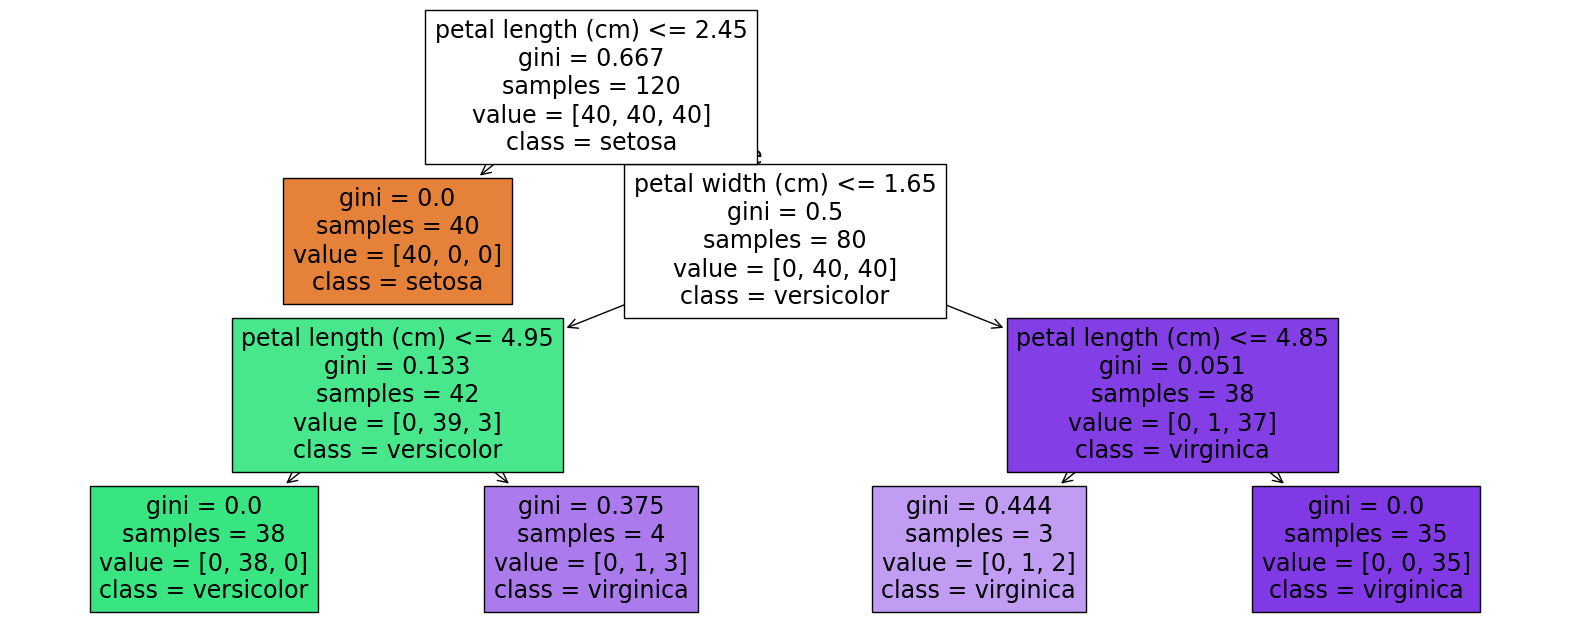

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt # Added import

dt = DecisionTreeClassifier(
    max_depth=4,         # evite l'overfitting
    min_samples_split=5, # noeud non divise si < 5 points
    random_state=42
    )
dt.fit(X_tr, y_tr) # Changed X_wine_tr, y_wine_tr to X_tr, y_tr
importances = dt.feature_importances_  # importance de chaque feature (Gini)

# Visualisation de l'arbre
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=iris.feature_names, # Changed wine.feature_names to iris.feature_names
          class_names=iris.target_names, filled=True, ax=ax) # Changed wine.target_names to iris.target_names

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

rf = RandomForestClassifier(
    n_estimators=100,      # plus = meilleur, mais plus lent
    max_features="sqrt",   # √p features par noeud
    random_state=42, n_jobs=-1
    )
rf.fit(X_tr, y_tr)

# Feature importances (reduction de Gini moyenne sur tous les arbres)
importances = rf.feature_importances_

# Diagnostiquer l'overfitting
train_sz, train_sc, test_sc = learning_curve(rf, X, y, cv=5)

Random Forest Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score # Added import for accuracy_score

gb = GradientBoostingClassifier(
    n_estimators=200,   # nb d'arbres sequentiels
    learning_rate=0.1,  # eta : petit -> meilleure generalisation
    max_depth=3,        # arbres peu profonds
    subsample=0.8,      # stochastic GBM
    random_state=42
    )
gb.fit(X_tr, y_tr) # Changed X_bc_tr, y_bc_tr to X_tr, y_tr
proba = gb.predict_proba(X_te)[:, 1]  # probabilite classe positive # Changed X_bc_te to X_te

# Convergence : accuracy par iteration
staged = [accuracy_score(y_te, p) for p in gb.staged_predict(X_te)] # Changed y_bc_te to y_te, X_bc_te to X_te

SVM — Support Vector Machine

In [ ]:
from sklearn.svm import SVC

svm = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
        ("svm", SVC(
                kernel="rbf",      # gaussien : polyvalent
                        C=1.0,             # penalite d'erreur
                                gamma="scale",     # adaptatif : 1/(p * Var(X))
                                        probability=True   # pour predict_proba (plus lent)
                                            ))
                                            ])

K-Nearest Neighbors (KNN)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline # Added import
from sklearn.preprocessing import StandardScaler # Added import
from sklearn.metrics import accuracy_score # Added import

# Trouver le k optimal
for k in range(1, 21):
    knn = Pipeline([("sc", StandardScaler()),
                        ("knn", KNeighborsClassifier(n_neighbors=k))])
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))

Naive Bayes (GaussianNB)

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()    # pas de normalisation necessaire
gnb.fit(X_tr, y_tr)
proba = gnb.predict_proba(X_te)   # probabilites posterieures calibrees

print(gnb.theta_)  # (n_classes, n_features) : moyennes par classe
print(gnb.var_)    # (n_classes, n_features) : variances par classe

[[4.985  3.415  1.4775 0.255 ]
 [5.93   2.75   4.2525 1.32  ]
 [6.61   2.98   5.58   2.04  ]]
[[0.092775   0.155275   0.02524375 0.012975  ]
 [0.2216     0.093      0.19149375 0.0341    ]
 [0.4574     0.1221     0.3236     0.0704    ]]


AdaBoost Classifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score # Added import

ada = AdaBoostClassifier(
    n_estimators=100, learning_rate=0.5,
    algorithm="SAMME", random_state=42
    )
ada.fit(X_tr, y_tr)

# Evolution de l'accuracy par iteration
staged_acc = [accuracy_score(y_te, p) for p in ada.staged_predict(X_te)]

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


MLP — Perceptron Multicouche

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline # Added import
from sklearn.preprocessing import StandardScaler # Added import

mlp = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),  # 3 couches cached
        activation="relu",
        solver="adam",
        max_iter=300,
        early_stopping=True,  # arret si val ne s'ameliore plus
        validation_fraction=0.1,
        random_state=42
    ))
])
mlp.fit(X_tr, y_tr)
loss_curve = mlp["mlp"].loss_curve_   # perte par iteration

10. Extra Trees Classifier


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
et.fit(X_tr, y_tr)
importances = et.feature_importances_

LDA — Analyse Discriminante Linéaire

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_tr, y_tr)

# Reduction de dimension (ex: Iris 4D -> 2D)
X_2d = lda.transform(X)   # projection sur les axes discriminants

QDA — Analyse Discriminante Quadratique

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis(reg_param=0.1)  # reg: evite singularite